In [60]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [61]:
data = pd.read_csv("/home/lev/Documents/Lab_MIPT/4/diffusion/data.csv")

In [62]:
data.dropna()

,U+AF8-ak,U+AF8-cap,U+AF8-acp,I,nu,razmach+AF8-input,razmach+AF8-output,otnoshenie


In [63]:
data

,U+AF8-ak,U+AF8-cap,U+AF8-acp,I,nu,razmach+AF8-input,razmach+AF8-output,otnoshenie
0,2,NaN,NaN,48179,0.1,100.0,1404559.0,NaN
1,5,NaN,NaN,34784,0.2,100.0,2039533.0,NaN
2,10,NaN,NaN,165523,0.5,100.0,2587991.0,NaN
3,15,NaN,NaN,370548,1.0,100.0,2901433.0,NaN
4,20,NaN,NaN,577433,2.0,100.0,2211914.0,NaN
5,30,NaN,NaN,738194,5.0,100.0,1816568.0,NaN
6,40,NaN,NaN,1028402,10.0,100.0,619801.0,NaN
7,50,NaN,NaN,1287944,20.0,100.0,332820.0,NaN
8,100,NaN,NaN,1476790,NaN,NaN,NaN,NaN
9,200,NaN,NaN,2161153,NaN,NaN,NaN,NaN


In [64]:
U_ak = data["U+AF8-ak"]
I = data["I"]

X = U_ak.to_numpy()
Y = I.to_numpy()

In [84]:
def stac(x, a, b):
    # b = (10** 4) *1.6 / 2 / 1.38 / 300
    return a * np.tanh(b * x)

In [89]:
popt, *pcov = curve_fit(stac, X, Y, p0=(-100, 10))

x_model = np.linspace(min(X), max(X), 1000)
y_model = stac(x_model, popt[0], popt[1])

popt[0], popt[1]

/tmp/ipykernel_633445/3472005384.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, *pcov = curve_fit(stac, X, Y, p0=(-100, 10))


(np.float64(2323943.761397257), np.float64(10.0))

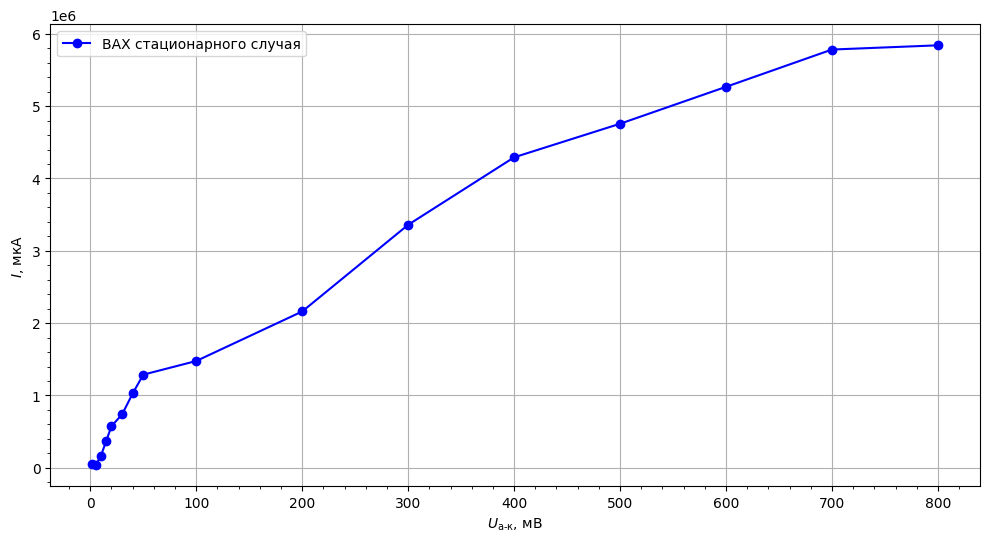

In [91]:


plt.figure(figsize=(12, 6))
plt.plot(U_ak, I, "-ob", label="ВАХ стационарного случая")

# plt.plot(x_model, y_model, color="red", label=f"Аппроксимация")

plt.xlabel("$U_\\text{а-к}$, мВ")
plt.ylabel("$I$, мкА")

plt.grid()
plt.minorticks_on()

plt.legend()

In [92]:
nu = data["nu"]
r_out = data["razmach+AF8-output"]
r_in = data["razmach+AF8-input"]

In [93]:
r = r_out / r_in

<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_633445/2366407242.py:5: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("$\omega$, Гц")


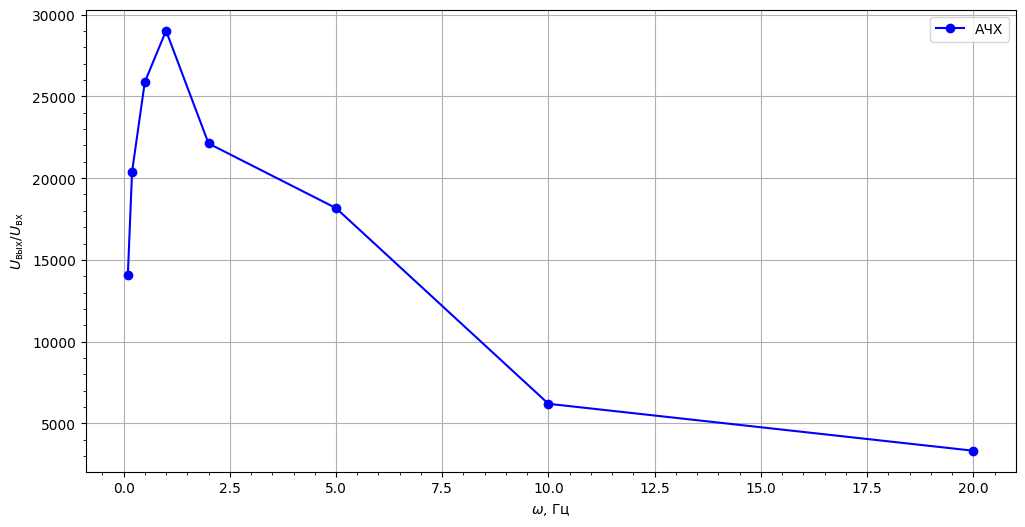

In [95]:
plt.figure(figsize=(12, 6))
plt.plot(nu, r, "-ob", label="АЧХ")


plt.xlabel("$\omega$, Гц")
plt.ylabel("$U_\\text{вых}/U_\\text{вх}$")

plt.grid()
plt.minorticks_on()

plt.legend()